<a href="https://colab.research.google.com/github/ibrahimbugrasan/HasarliAracTespiti-2/blob/main/SwinModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model eğitimine başlıyor...


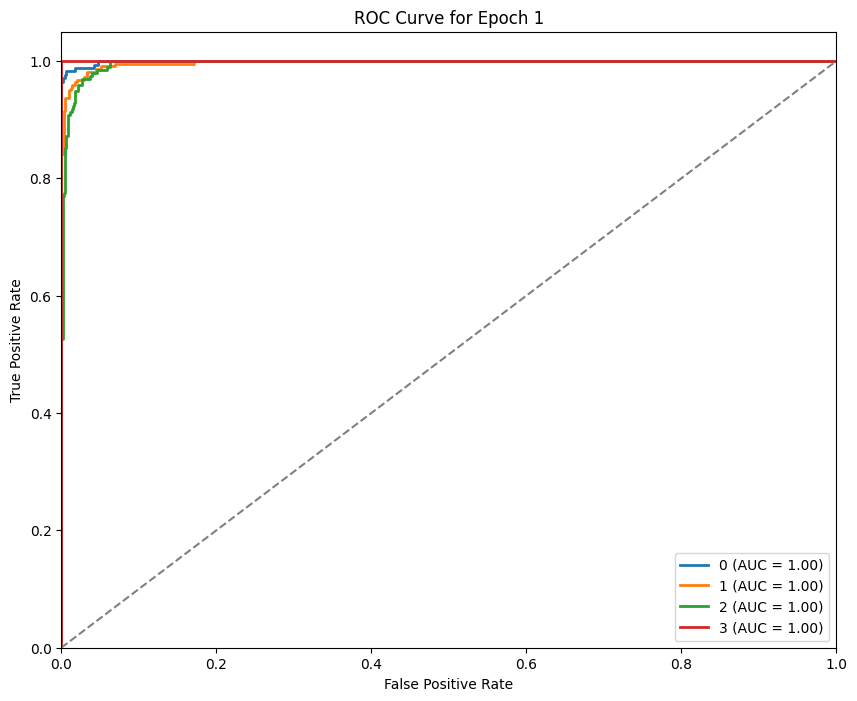

Epoch 1/10
Train Loss: 0.4522
Accuracy: 0.9613, Recall: 0.9613, Precision: 0.9642
Sensitivity: [0.9952380952380953, 0.9965457685664939, 0.956953642384106, 1.0], Specificity: [0.9705882352941176, 0.9004524886877828, 0.9795918367346939, 1.0]
F1 Score: 0.9615, AUC: 0.9981
Epoch Time: 56.79s, Inference Time: 6.72s


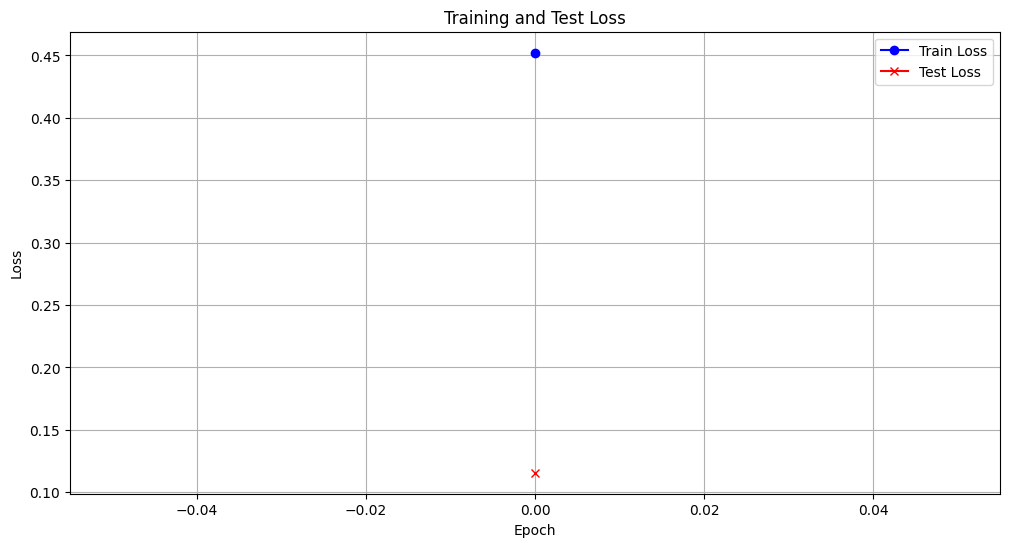

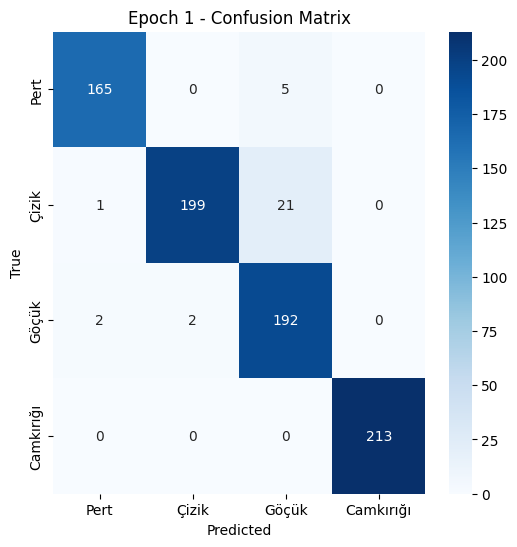

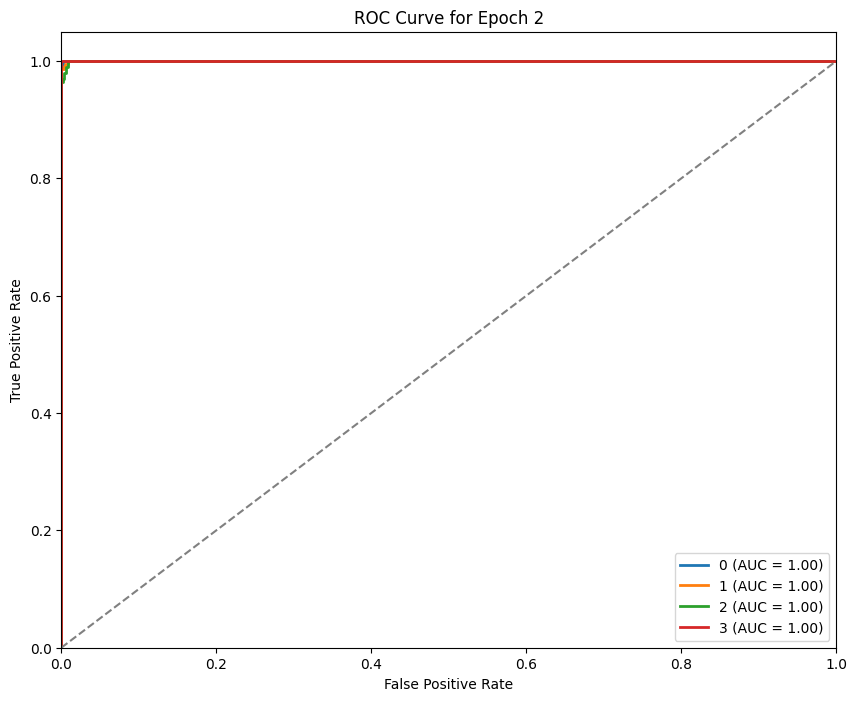

Epoch 2/10
Train Loss: 0.0457
Accuracy: 0.9925, Recall: 0.9925, Precision: 0.9926
Sensitivity: [1.0, 0.998272884283247, 0.9917218543046358, 1.0], Specificity: [0.9882352941176471, 0.9864253393665159, 0.9948979591836735, 1.0]
F1 Score: 0.9925, AUC: 0.9999
Epoch Time: 54.83s, Inference Time: 6.47s


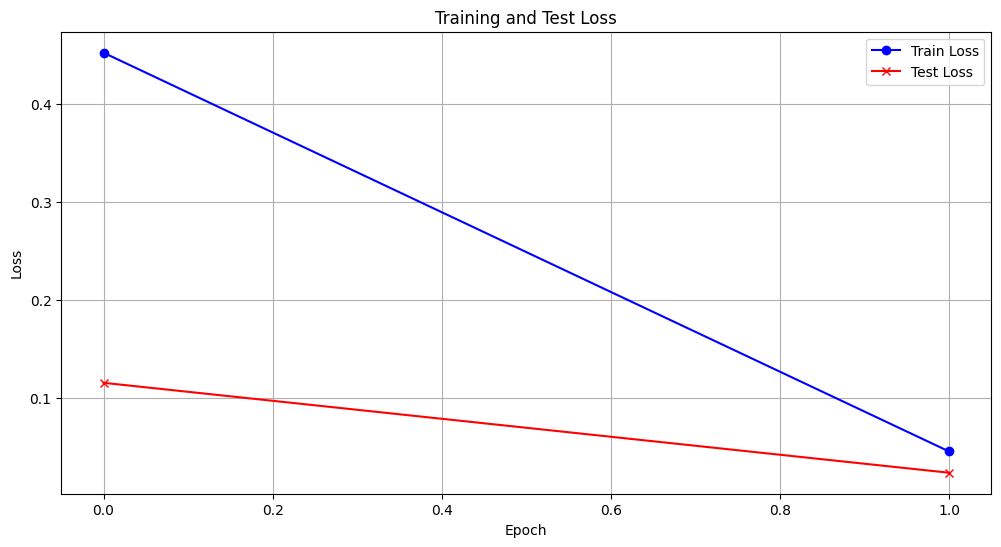

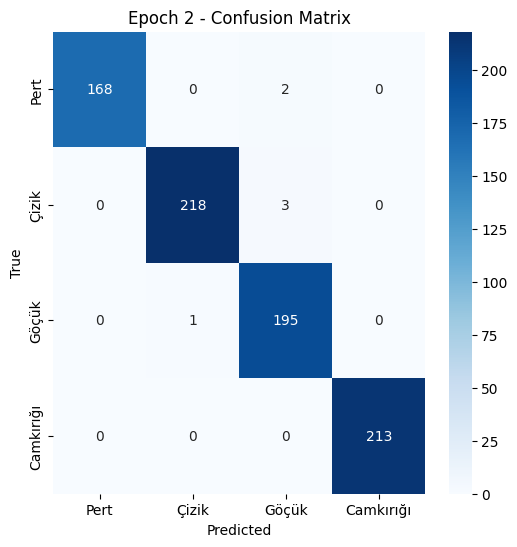

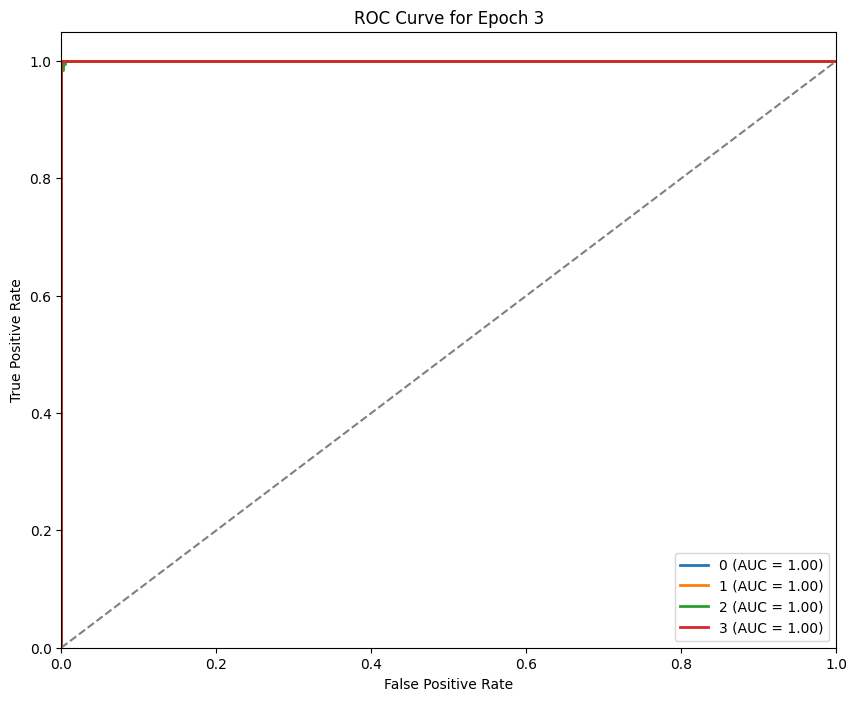

Epoch 3/10
Train Loss: 0.0137
Accuracy: 0.9962, Recall: 0.9962, Precision: 0.9963
Sensitivity: [0.9984126984126984, 1.0, 0.9966887417218543, 1.0], Specificity: [0.9882352941176471, 1.0, 0.9948979591836735, 1.0]
F1 Score: 0.9962, AUC: 1.0000
Epoch Time: 53.66s, Inference Time: 6.80s


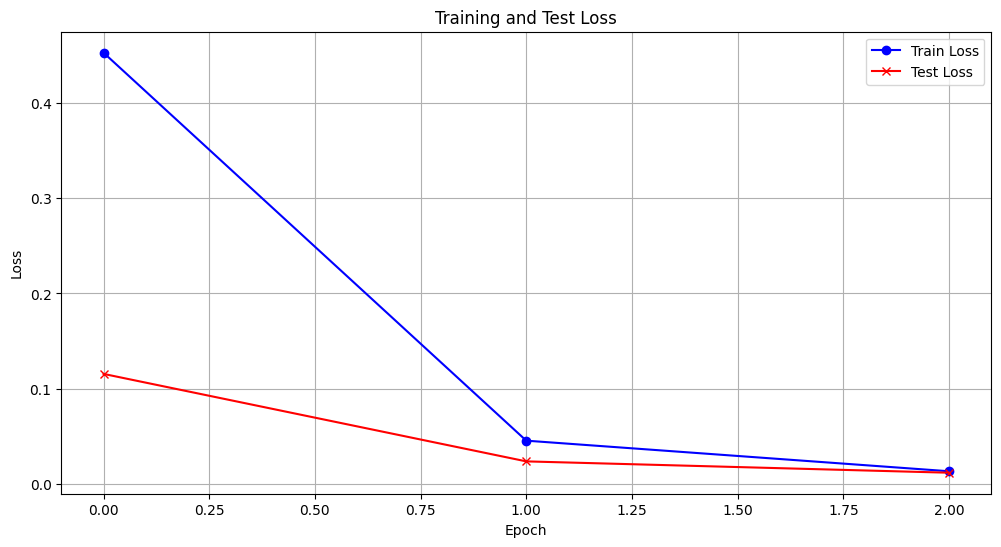

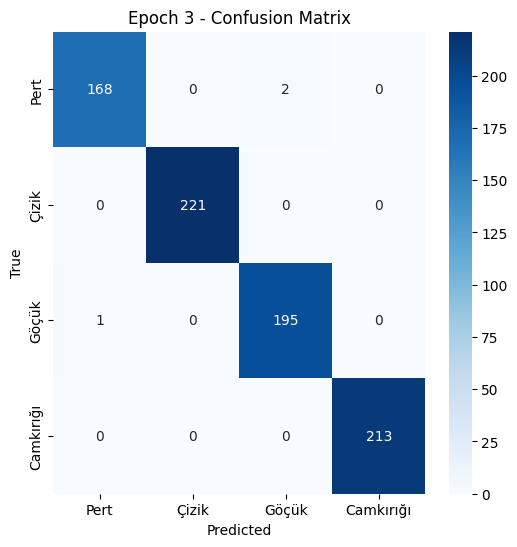

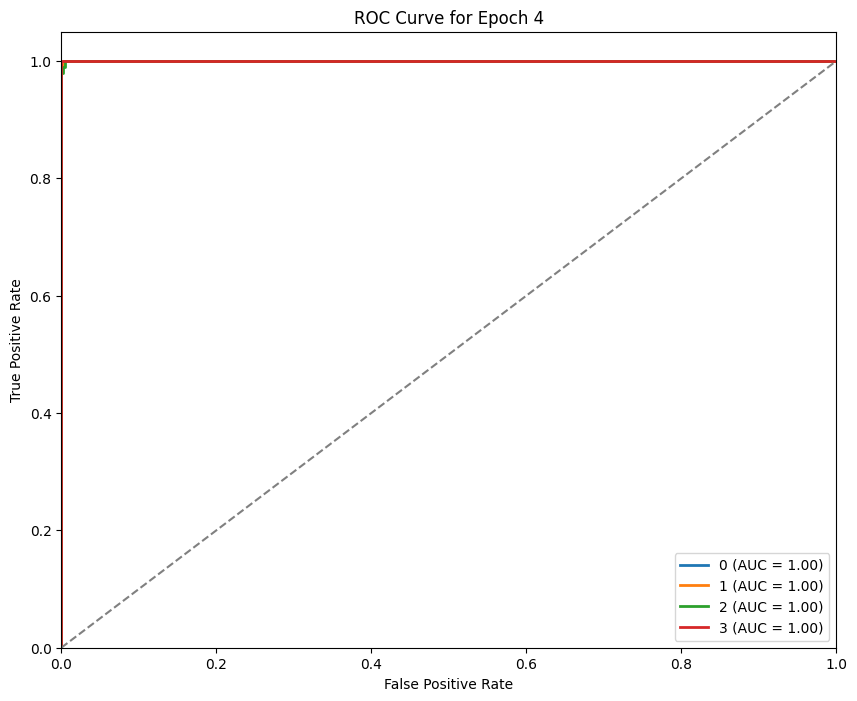

Epoch 4/10
Train Loss: 0.0092
Accuracy: 0.9912, Recall: 0.9912, Precision: 0.9916
Sensitivity: [1.0, 1.0, 0.9884105960264901, 1.0], Specificity: [0.9882352941176471, 0.9773755656108597, 1.0, 1.0]
F1 Score: 0.9913, AUC: 1.0000
Epoch Time: 53.27s, Inference Time: 6.59s


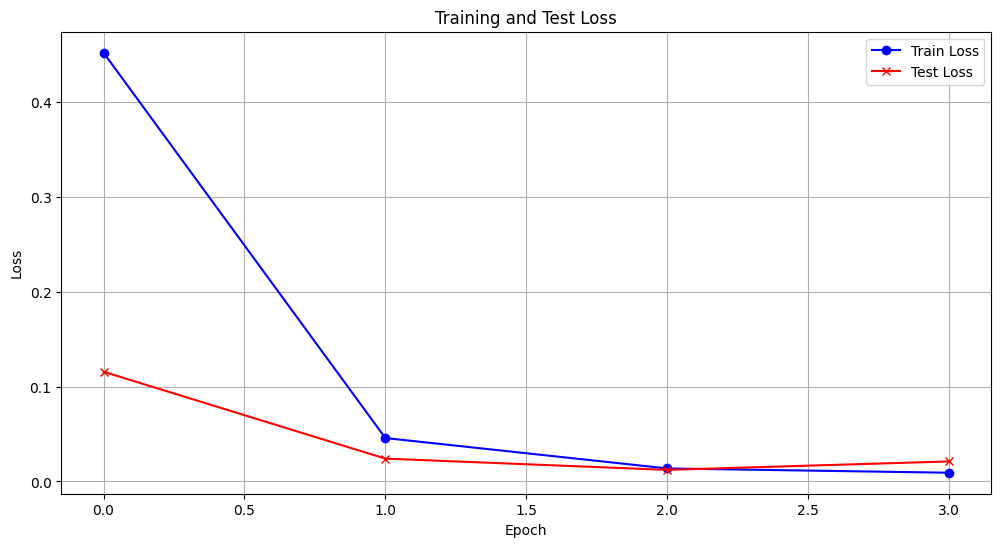

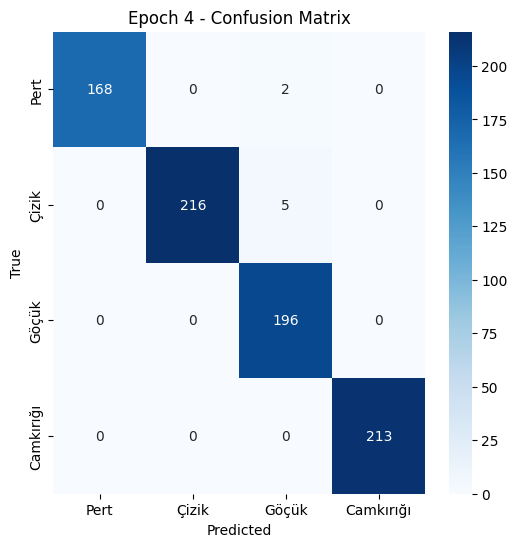

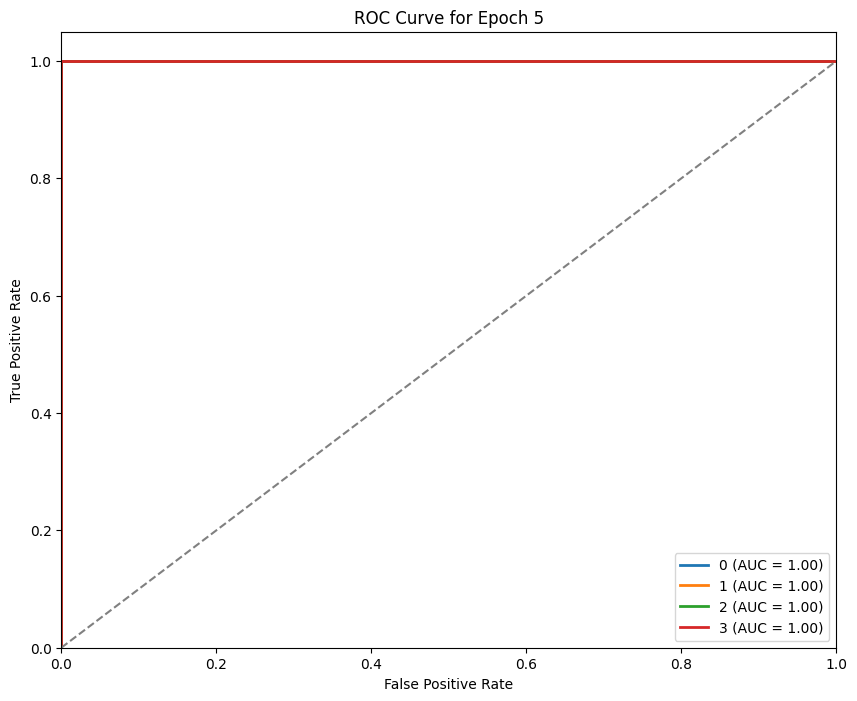

Epoch 5/10
Train Loss: 0.0039
Accuracy: 0.9988, Recall: 0.9988, Precision: 0.9988
Sensitivity: [1.0, 1.0, 0.9983443708609272, 1.0], Specificity: [0.9941176470588236, 1.0, 1.0, 1.0]
F1 Score: 0.9987, AUC: 1.0000
Epoch Time: 53.34s, Inference Time: 6.71s


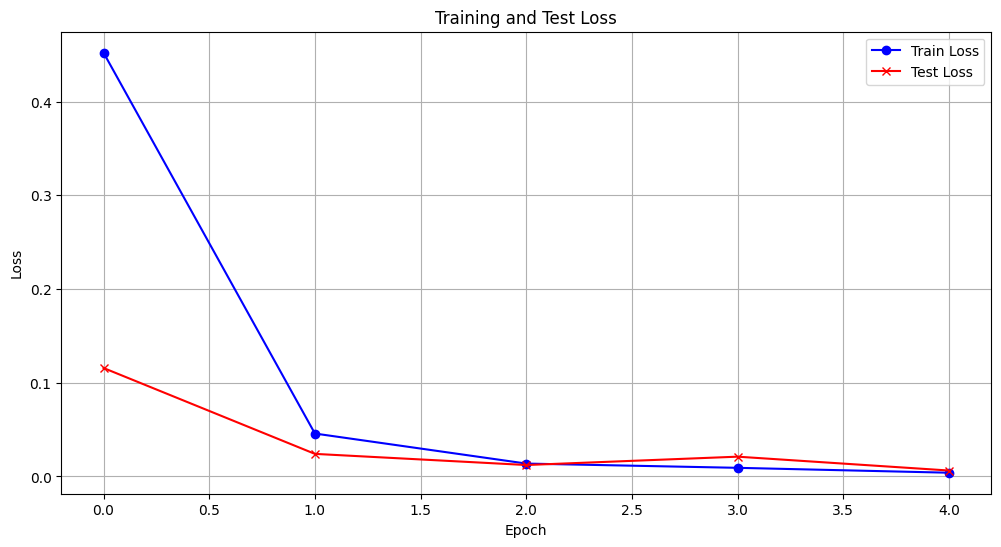

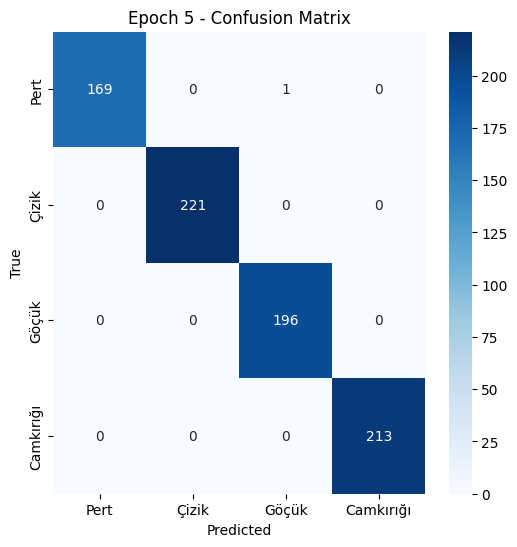

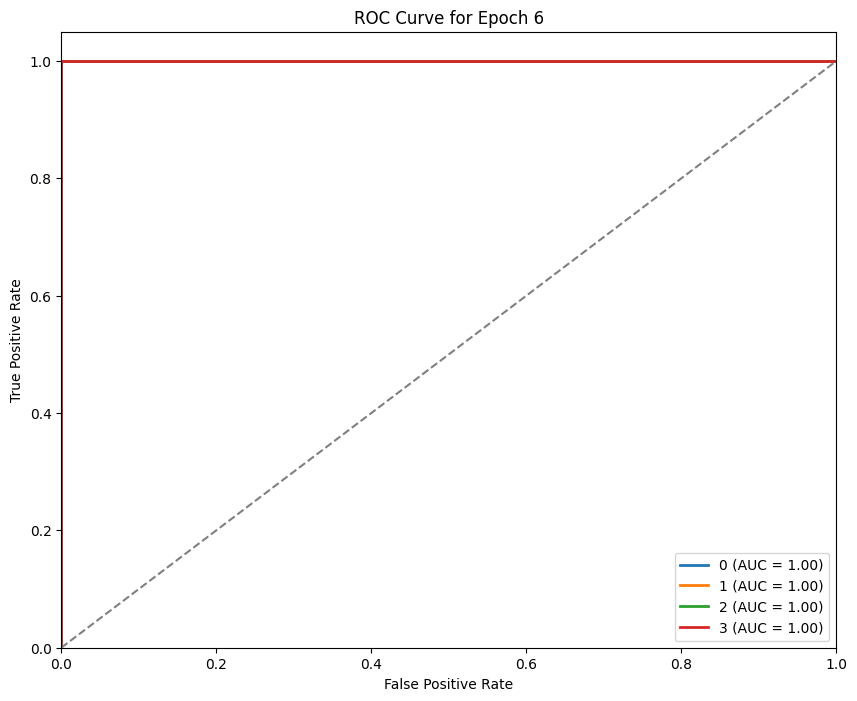

Epoch 6/10
Train Loss: 0.0024
Accuracy: 0.9988, Recall: 0.9988, Precision: 0.9988
Sensitivity: [0.9984126984126984, 1.0, 1.0, 1.0], Specificity: [1.0, 1.0, 0.9948979591836735, 1.0]
F1 Score: 0.9988, AUC: 1.0000
Epoch Time: 53.65s, Inference Time: 6.77s


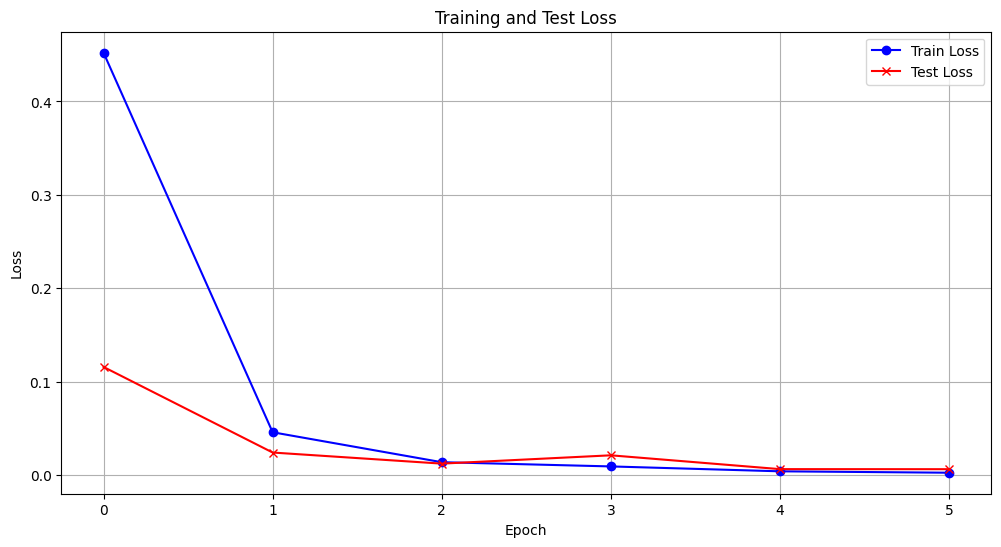

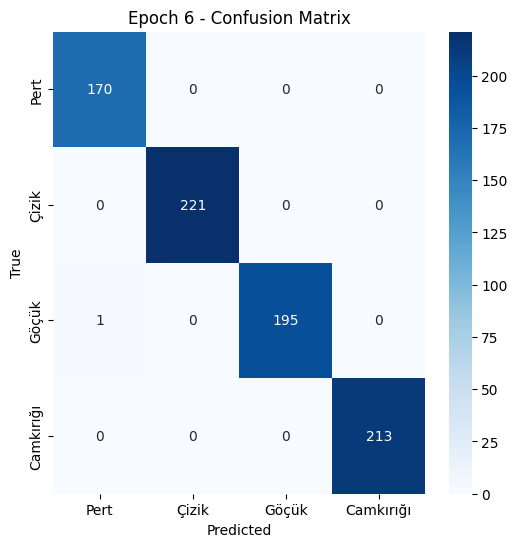

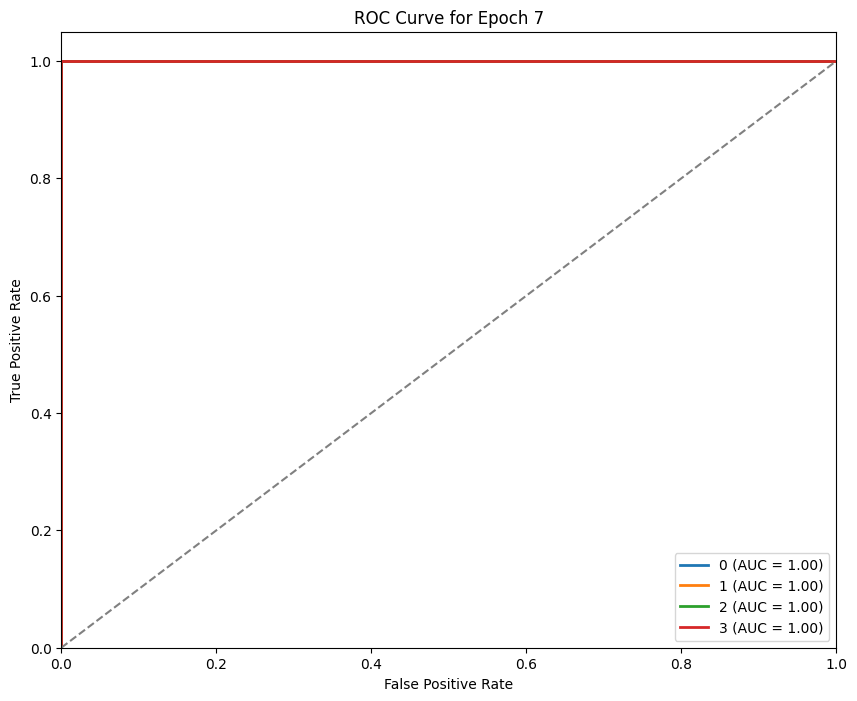

Epoch 7/10
Train Loss: 0.0012
Accuracy: 0.9975, Recall: 0.9975, Precision: 0.9975
Sensitivity: [1.0, 1.0, 0.9966887417218543, 1.0], Specificity: [0.9941176470588236, 0.995475113122172, 1.0, 1.0]
F1 Score: 0.9975, AUC: 1.0000
Epoch Time: 53.46s, Inference Time: 6.46s


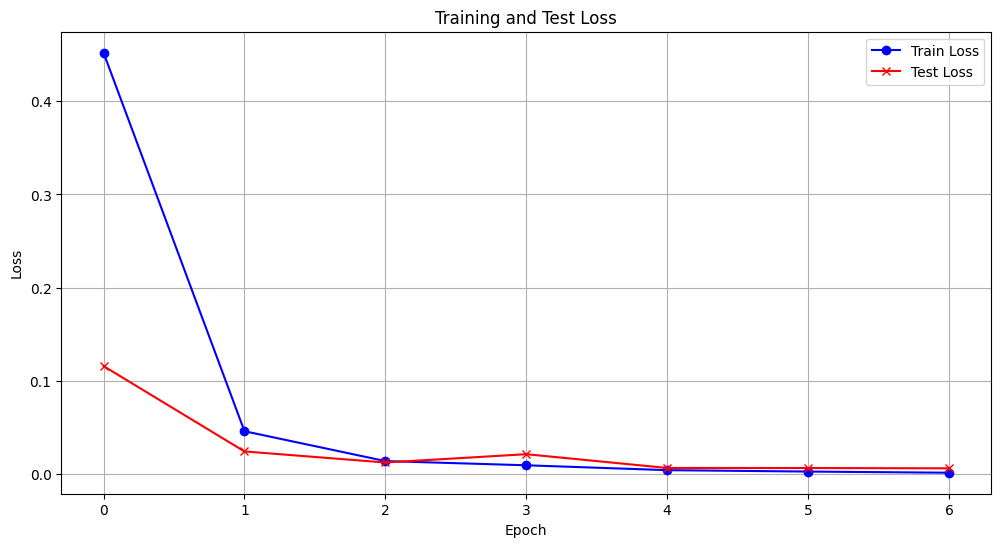

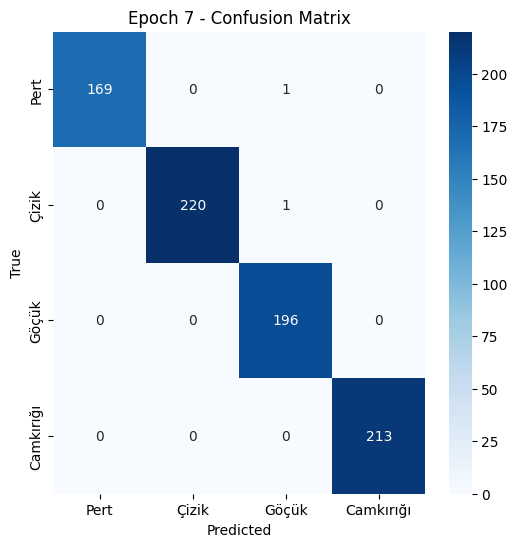

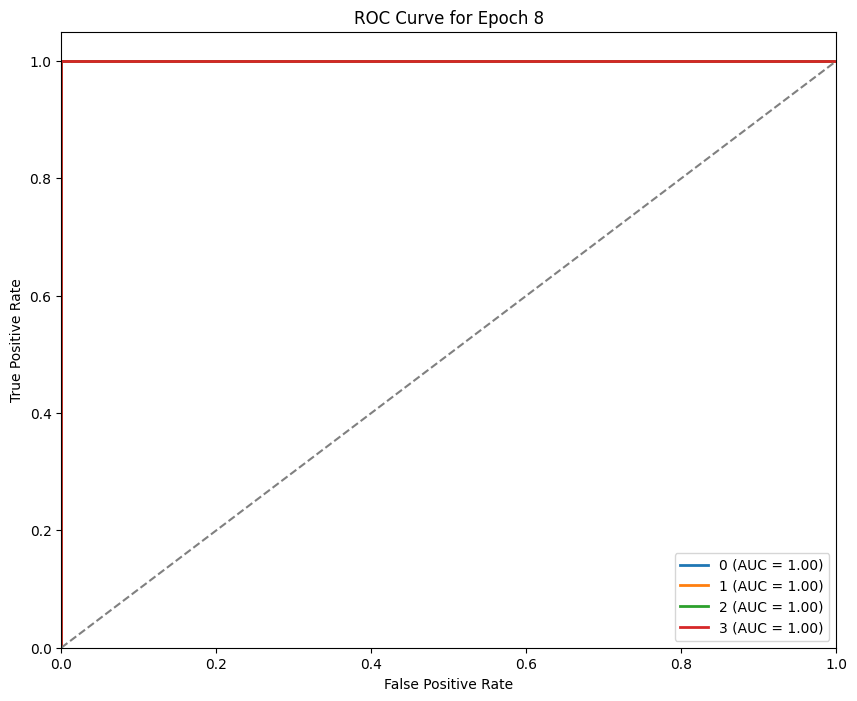

Epoch 8/10
Train Loss: 0.0013
Accuracy: 1.0000, Recall: 1.0000, Precision: 1.0000
Sensitivity: [1.0, 1.0, 1.0, 1.0], Specificity: [1.0, 1.0, 1.0, 1.0]
F1 Score: 1.0000, AUC: 1.0000
Epoch Time: 53.59s, Inference Time: 6.84s


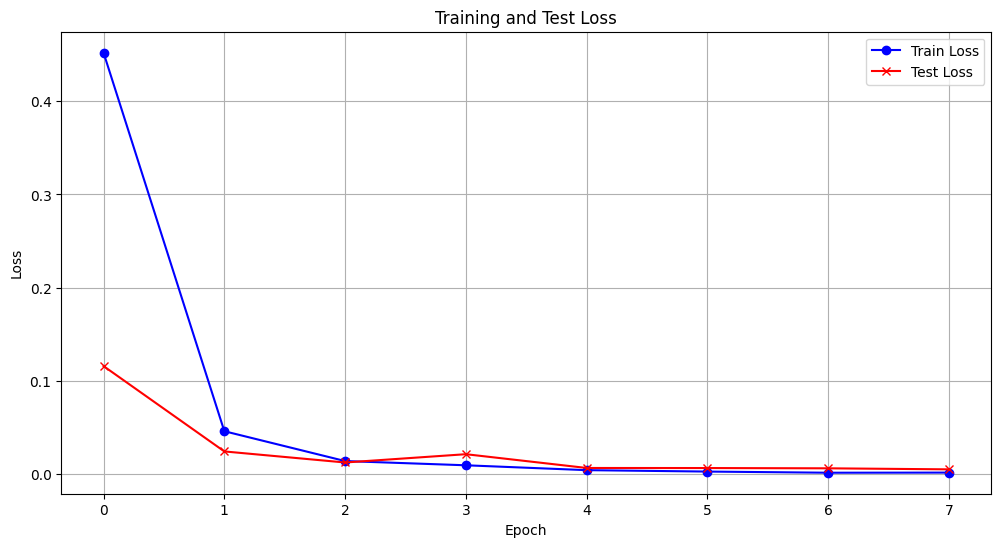

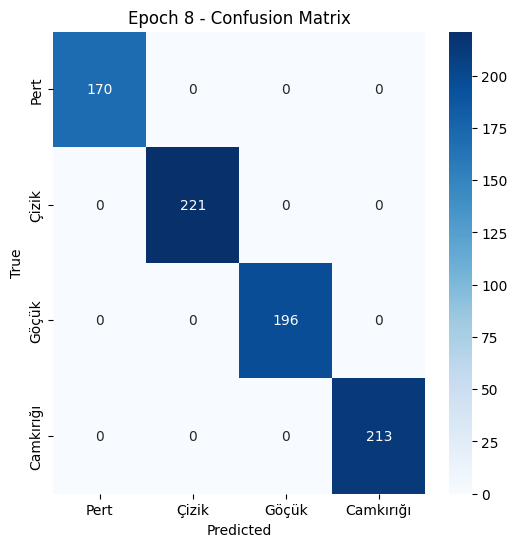

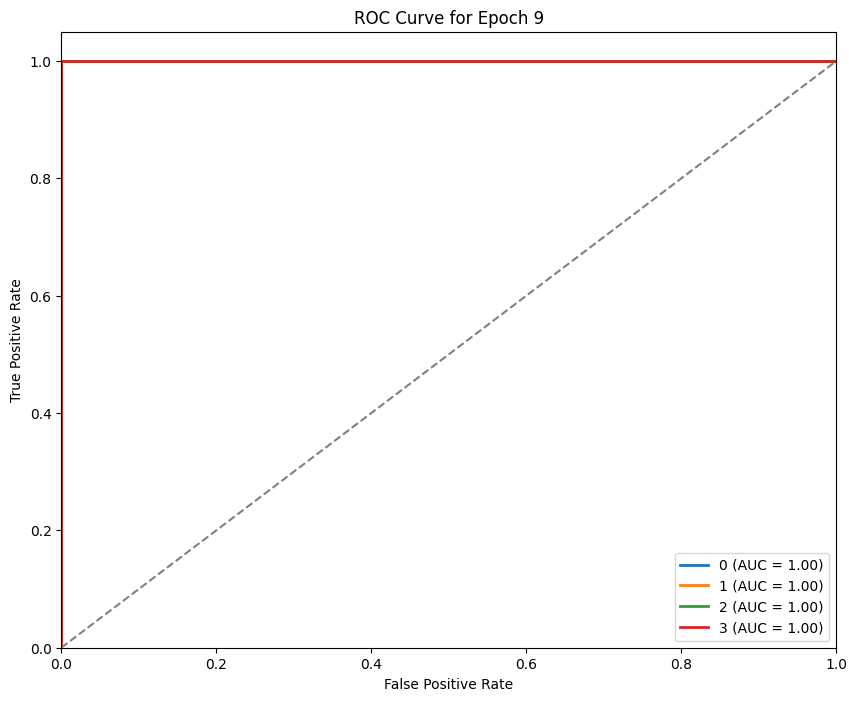

Epoch 9/10
Train Loss: 0.0009
Accuracy: 0.9988, Recall: 0.9988, Precision: 0.9988
Sensitivity: [1.0, 1.0, 0.9983443708609272, 1.0], Specificity: [0.9941176470588236, 1.0, 1.0, 1.0]
F1 Score: 0.9987, AUC: 1.0000
Epoch Time: 53.30s, Inference Time: 6.48s


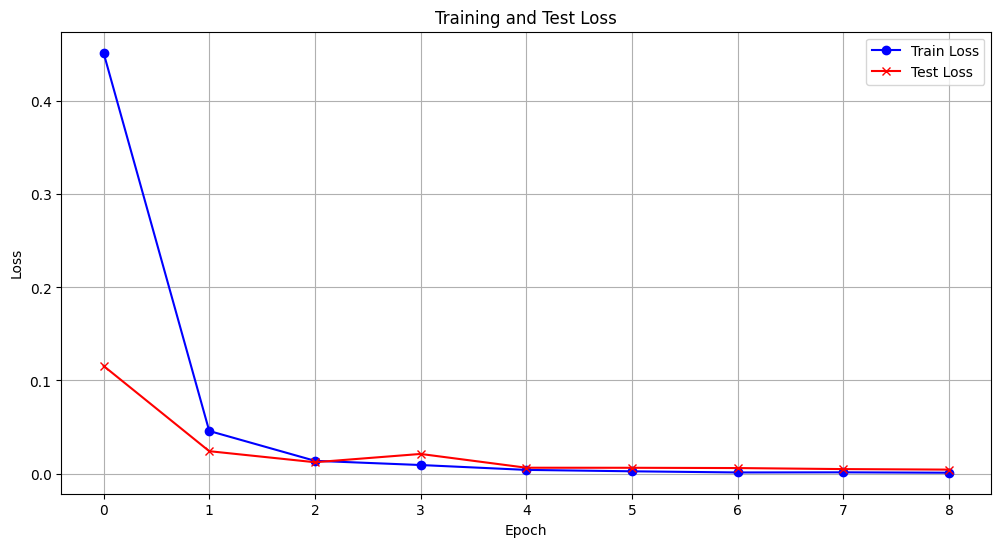

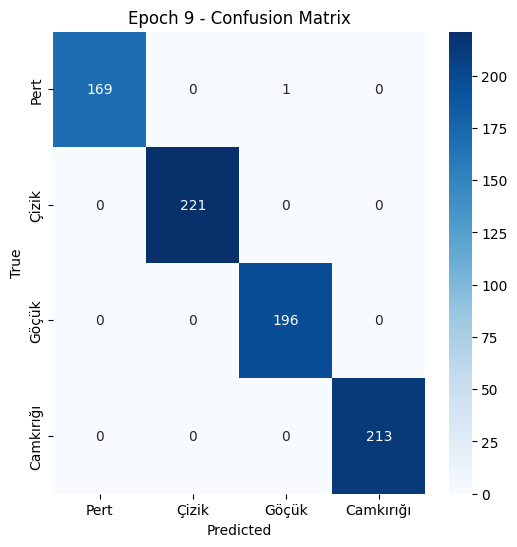

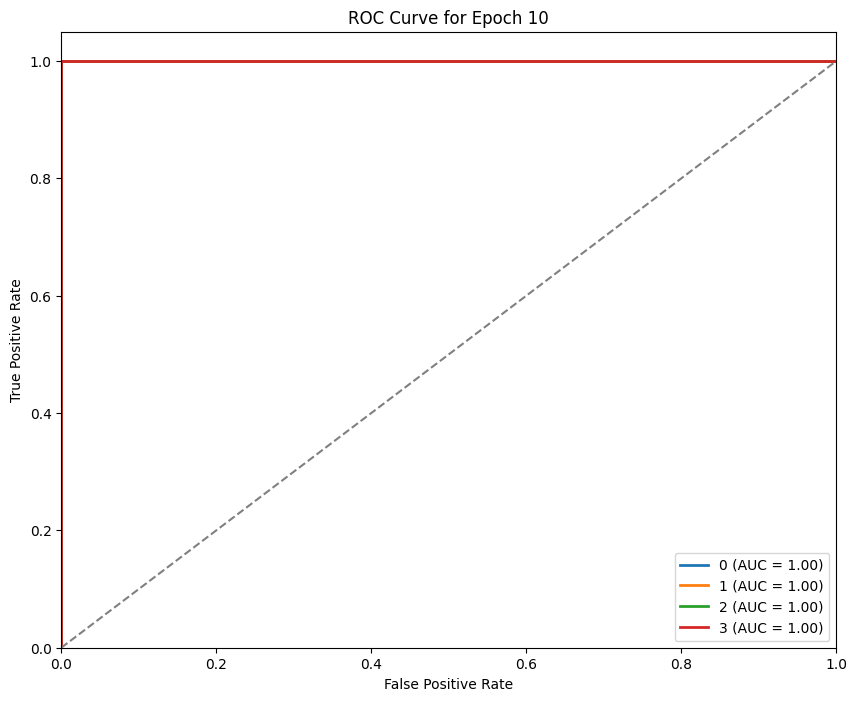

Epoch 10/10
Train Loss: 0.0008
Accuracy: 0.9988, Recall: 0.9988, Precision: 0.9988
Sensitivity: [1.0, 1.0, 0.9983443708609272, 1.0], Specificity: [0.9941176470588236, 1.0, 1.0, 1.0]
F1 Score: 0.9987, AUC: 1.0000
Epoch Time: 53.25s, Inference Time: 6.71s


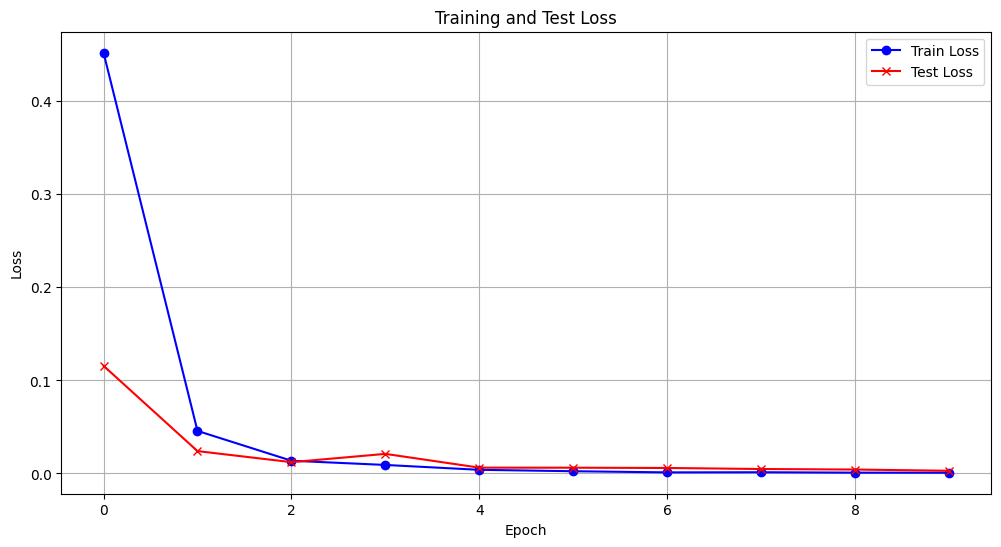

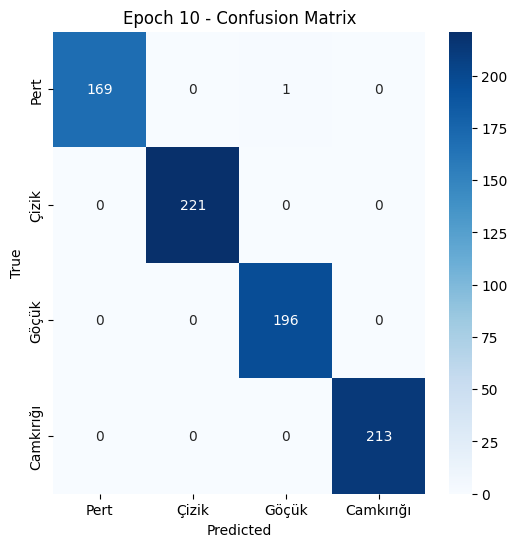

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from transformers import SwinForImageClassification, SwinConfig
from google.colab import drive

# Swin Tiny modelini yükleyelim
model_name = 'microsoft/swin-tiny-patch4-window7-224'
model = SwinForImageClassification.from_pretrained(model_name, num_labels=4, ignore_mismatched_sizes=True)
model.classifier = torch.nn.Linear(model.classifier.in_features, 4)

# Veri yükleme kısmı (Google Drive üzerinde verinizi yükleyin)
drive.mount('/content/drive')

# Veriyi burada uygun şekilde yükleyin (örneğin, 'all_data' klasörü altında)
full_data = torchvision.datasets.ImageFolder('/content/drive/MyDrive/YazLabProjesi/DATABASE', transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]))

# Eğitim ve test verisi ayırma işlemi (Veriyi %80 eğitim, %20 test olarak ayıralım)
train_size = int(0.8 * len(full_data))
test_size = len(full_data) - train_size
train_data, test_data = torch.utils.data.random_split(full_data, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=16, shuffle=False)

# 2. Eğitim Ayarları
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# 3. Eğitim Fonksiyonu
def train_model(model, train_loader, test_loader, epochs=10,):
    train_losses, test_losses = [], []
    accuracies, recalls, precisions, f1_scores, aucs = [], [], [], [], []
    confusion_matrices = []
    epoch_times, inference_times = [], []
    epoch_train_losses = []  # Train loss for each epoch
    epoch_test_losses = []   # Test loss for each epoch

    print("Model eğitimine başlıyor...")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()

        # Eğitim
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).logits
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)

        epoch_train_losses.append(running_loss / len(train_loader))

        # Test (Doğrulama)
        model.eval()
        all_preds = []
        all_labels = []
        all_outputs = []  # Sınıf olasılıklarını tutmak için ekliyoruz
        start_inference = time.time()

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).logits
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())  # Olasılıkları kaydediyoruz

        # One-hot encoding için LabelBinarizer kullanarak all_labels'ı dönüştür
        lb = LabelBinarizer()
        all_labels_one_hot = lb.fit_transform(all_labels)

        # Softmax ile olasılıkları elde et
        all_outputs_softmax = torch.softmax(torch.tensor(all_outputs), dim=1).numpy()

        # ROC eğrisini hesapla ve çiz
        plot_roc_curve(all_labels_one_hot, all_outputs_softmax, lb.classes_, epoch)

        # Accuracy, Recall, Precision, F1, AUC hesaplama
        accuracy = accuracy_score(all_labels, all_preds)
        recall = recall_score(all_labels, all_preds, average='weighted')
        precision = precision_score(all_labels, all_preds, average='weighted')
        f1 = f1_score(all_labels, all_preds, average='weighted')
        auc_value = roc_auc_score(all_labels, all_outputs_softmax, multi_class='ovr', average='weighted')

        accuracies.append(accuracy)
        recalls.append(recall)
        precisions.append(precision)
        f1_scores.append(f1)
        aucs.append(auc_value)

        # Confusion matrix hesaplama
        cm = confusion_matrix(all_labels, all_preds)
        confusion_matrices.append(cm)

        # Sensitivity (Duyarlılık) ve Specificity (Özgüllük) hesaplama
        sensitivity = []
        specificity = []
        for i in range(4):  # 4 sınıf için
            tn, fp, fn, tp = cm[i, i], cm[i, :].sum() - cm[i, i], cm[:, i].sum() - cm[i, i], cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
            sensitivity.append(tp / (tp + fn) if (tp + fn) > 0 else 0)  # True Positive Rate
            specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0)  # True Negative Rate

        # Epoch sürelerini ve inference zamanını yazdırma
        inference_time = time.time() - start_inference
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {running_loss / len(train_loader):.4f}")
        print(f"Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")
        print(f"Sensitivity: {sensitivity}, Specificity: {specificity}")
        print(f"F1 Score: {f1:.4f}, AUC: {auc_value:.4f}")
        print(f"Epoch Time: {epoch_time:.2f}s, Inference Time: {inference_time:.2f}s")

        epoch_test_losses.append(criterion(torch.tensor(all_outputs), torch.tensor(all_labels)).item())  # Test loss

        # Grafiklerin gösterimi
        plot_loss_graph(epoch_train_losses, epoch_test_losses)
        plot_confusion_matrix(cm, epoch)

# 4. Yardımcı Fonksiyonlar
def plot_loss_graph(train_losses, test_losses):
    plt.figure(figsize=(12, 6))
    plt.plot(train_losses, label='Train Loss', color='blue', linestyle='-', marker='o')
    plt.plot(test_losses, label='Test Loss', color='red', linestyle='-', marker='x')
    plt.legend()
    plt.title('Training and Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

def plot_confusion_matrix(cm, epoch):
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pert', 'Çizik', 'Göçük', 'Camkırığı'], yticklabels=['Pert', 'Çizik', 'Göçük', 'Camkırığı'])
    plt.title(f'Epoch {epoch+1} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def plot_roc_curve(y_true, y_score, class_names, epoch):
    # ROC Eğrisini Çizme
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        auc_value = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {auc_value:.2f})')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Epoch {epoch+1}')
    plt.legend(loc='lower right')
    plt.show()

# 5. Modeli Eğitme
train_model(model, train_loader, test_loader, epochs=10,)